In [93]:
# Setup
import sys, os, time, math, random, subprocess
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root("src")

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Project imports & model builders
from src.data.prepare_dataset import build_pairs_for_split
from src.data.dataloader import make_loaders
from src.data.augmentations import get_val_augs

# Baseline: adjust import to your baseline class if different
from src.models.orig_unet import UNet as BaselineUNet

# Proposed wrapper
from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation
Device: cuda


In [94]:
# Configuration 
 
# ---- datasets ----
DATASETS = {
    "DRIVE":     dict(root="../../data/raw/DRIVE",     label_folder="1st_manual"),
    "CHASE-DB1": dict(root="../../data/raw/CHASEDB1", label_folder="1st_manual"),
    "STARE":     dict(root="../../data/raw/STARE",     label_folder="1st_manual"),
}

# ---- checkpoints ----
CKPTS = {
    "DRIVE": {
        "unet":     "../../outputs/checkpoints/unet/[DRIVE] base_unet.pth",
        "proposed": "../../outputs/checkpoints/[DRIVE] MATHFI.pth",
    },
    "CHASE-DB1": {
        "unet":     "../../outputs/checkpoints/unet/[CHASEDB1] base_unet.pth",
        "proposed": "../../outputs/checkpoints/[CHASEDB1] MATHFI.pth",
    },
    "STARE": {
        "unet":     "../../outputs/checkpoints/unet/[STARE] base_unet.pth",
        "proposed": "../../outputs/checkpoints/[STARE] MATHFI.pth",
    },
}

# ---- evaluation hyperparams ----
IMAGE_SIZE = 512      # val/test preprocessing size
TAU        = 0.5      # decision threshold for binarizing probs
NUM_WORKERS = 0       # safe locally; bump on Linux if desired
BATCH_SIZE  = 1
WINDOW      = IMAGE_SIZE   # sliding-window tile size
OVERLAP     = 0.25

# ---- proposed model (DPCN) hyperparams per dataset (MUST MATCH TRAINING) ----
# If trained the same way for all datasets, keep a single block.
PROPOSED_CFG = {
    "default": dict(enh_channels=64, iters=6, threshold_mode="scaled_vat", half_life=2.0, reduce_to=64),
    # Example: override per dataset (uncomment and edit if needed)
    # "DRIVE":   dict(enh_channels=32, iters=8, threshold_mode="scaled_vat", half_life=4.2, reduce_to=56),
    # "STARE":   dict(enh_channels=64, iters=6, threshold_mode="scaled_vat", half_life=2.8, reduce_to=64),
}

# ---- base UNet extras (as used in your code) ----
BASE_KW = {"cbam_reduction": 16}

# Where to dump CSVs (optional)
OUT_DIR = Path("./eval_exports"); OUT_DIR.mkdir(parents=True, exist_ok=True)


In [95]:
def build_model(model_name: str, dataset_name: str):
    if model_name == "unet":
        m = BaselineUNet(in_channels=1, out_channels=2)
    elif model_name == "proposed":
        cfg = PROPOSED_CFG.get(dataset_name, PROPOSED_CFG["default"])
        m = DPCNConcatUNet(
            in_ch=1,
            enh_channels=cfg["enh_channels"],
            iters=cfg["iters"],
            threshold_mode=cfg["threshold_mode"],
            half_life=cfg["half_life"],
            reduce_to=cfg["reduce_to"],
            base_kwargs=BASE_KW
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return m.to(DEVICE).eval()

def load_weights(model: torch.nn.Module, path: str):
    if not Path(path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)
    return model.eval()


In [96]:
# Build a test loader for each dataset (full-image mode)

def make_test_loader_for_dataset(root, label_folder, image_size=512, batch_size=1, num_workers=0, seed=SEED):
    test_pairs = build_pairs_for_split(root, split="test", label_folder=label_folder)

    # Pass test_pairs as both train/val to get a pure test loader (deterministic)
    _, test_loader = make_loaders(
        train_pairs=test_pairs,
        val_pairs=test_pairs,
        image_size=image_size,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        strict_fov=True,
        augs_train=None,
        augs_val=get_val_augs(image_size),
        patch_train=False
    )
    return test_loader


In [97]:
# ---- Normalizers to always get a single foreground LOGIT [1,1,H,W] ----
import torch

@torch.no_grad()
def _to_binary_logit_1chw(out_1BCHW: torch.Tensor) -> torch.Tensor:
    """
    Normalize any model output to a single-channel *logit* [1,1,h,w].
    Handles:
      - [1,1,h,w] raw logits  -> return as-is
      - [1,1,h,w] probabilities in [0,1] -> logit(prob)
      - [1,2,h,w] softmax probabilities -> logit(P_fg)
      - [1,2,h,w] raw logits -> (l_fg - l_bg)
    """
    if out_1BCHW.ndim != 4 or out_1BCHW.size(0) != 1:
        raise ValueError(f"expected [1,C,H,W], got {tuple(out_1BCHW.shape)}")
    C = out_1BCHW.shape[1]

    if C == 1:
        mn, mx = float(out_1BCHW.min()), float(out_1BCHW.max())
        if -1e-6 <= mn and mx <= 1.0 + 1e-6:          # looks like probs
            p = out_1BCHW.clamp(1e-6, 1-1e-6)
            return torch.logit(p)
        return out_1BCHW                                # logits already

    if C == 2:
        mn, mx = float(out_1BCHW.min()), float(out_1BCHW.max())
        if -1e-6 <= mn and mx <= 1.0 + 1e-6:           # might be softmax probs
            s = out_1BCHW.sum(dim=1, keepdim=True)
            if torch.allclose(s, torch.ones_like(s), atol=1e-3):
                p_fg = out_1BCHW[:, 1:2].clamp(1e-6, 1-1e-6)
                return torch.logit(p_fg)
        return out_1BCHW[:, 1:2] - out_1BCHW[:, 0:1]    # raw logits → binary logit

    raise ValueError(f"expected 1 or 2 output channels, got {C}")

@torch.no_grad()
def forward_to_logits_1chw(model, x_1chw, device="cuda"):
    """
    Single-pass (no tiling) forward → logits [1,1,H,W].
    Use this when your test image is already IMAGE_SIZE (e.g., 512×512).
    """
    model.eval()
    x = x_1chw.to(device, non_blocking=True)
    with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
        out = model(x)  # [1,C,H,W]
    logit = _to_binary_logit_1chw(out).to(device)
    return logit  # [1,1,H,W]

@torch.no_grad()
def sliding_window_forward_logits_1chw(model, img_1chw, window=512, overlap=0.25, device="cuda"):
    """
    Tiled inference → single-channel foreground *logit* [1,1,H,W].
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    acc  = torch.zeros((1,1,H,W), device=device, dtype=img.dtype)
    norm = torch.zeros_like(acc)

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                out = model(tile)                      # [1,C,win,win]
            logit = _to_binary_logit_1chw(out)         # [1,1,win,win]
            acc[:, :, y0:y1, x0:x1]  += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    return acc / torch.clamp_min(norm, 1.0)            # [1,1,H,W]



In [98]:
# sliding-window that handles 1- or 2-channel outputs
@torch.no_grad()
def sliding_window_forward_logits(model, img_1chw, window=512, overlap=0.25, device="cuda"):
    """
    Returns a single-channel foreground *logit* map [1,1,H,W],
    regardless of whether the model outputs [B,1,H,W] or [B,2,H,W].
    If 2ch:
      - If it's *probabilities* (softmaxed) -> convert to log-odds via logit(p_fg).
      - Else (raw logits) -> use (logit_fg - logit_bg), equivalent to binary logit.
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    acc  = None  # lazy init after first forward with correct [1,1,h,w]
    norm = None

    def _to_binary_logit(out):
        """
        out: [1,C,h,w] with C in {1,2}. Returns [1,1,h,w] binary logit for foreground.
        """
        if out.shape[1] == 1:
            return out  # already binary logit/prob; we treat as logit downstream
        elif out.shape[1] == 2:
            # Heuristic: check if outputs look like softmax probabilities
            # (values in [0,1] and sum over classes ~ 1).
            with torch.no_grad():
                is_prob = (out.min() >= 0.0) and (out.max() <= 1.0)
                if is_prob:
                    s = out.sum(dim=1, keepdim=True)
                    if torch.allclose(s, torch.ones_like(s), atol=1e-3):
                        p_fg = out[:, 1:2]
                        # Convert probs to logits so later torch.sigmoid(logit) == p_fg
                        return torch.logit(p_fg.clamp(1e-6, 1-1e-6))
            # Otherwise assume raw logits for CE: foreground logit = l1 - l0
            return out[:, 1:2] - out[:, 0:1]
        else:
            raise RuntimeError(f"Expected 1 or 2 output channels, got {out.shape[1]}")

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]                     # [1,1,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                out = model(tile)                               # [1,C,win,win]
            logit = _to_binary_logit(out)                       # [1,1,win,win]

            # lazy init acc/norm with correct shape
            if acc is None:
                acc  = torch.zeros_like(img[:, :1], device=device)  # [1,1,H,W]
                norm = torch.zeros_like(img[:, :1], device=device)

            acc[:, :, y0:y1, x0:x1] += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    logits = acc / torch.clamp_min(norm, 1.0)
    return logits  # [1,1,H,W] binary logit


In [99]:
# Metrics (SEN, SPE, clDice) computed inside FOV

def _mask_flatten(p, t, m=None):
    if m is None: return p.view(-1), t.view(-1)
    return (p*m).view(-1), (t*m).view(-1)

@torch.no_grad()
def sensitivity_specificity(pred01, targ01, mask01=None, eps=1e-6):
    p, t = _mask_flatten(pred01, targ01, mask01)
    tp = (p*t).sum()
    tn = ((1-p)*(1-t)).sum()
    fp = (p*(1-t)).sum()
    fn = ((1-p)*t).sum()
    sen = (tp + eps) / (tp + fn + eps)
    spe = (tn + eps) / (tn + fp + eps)
    return float(sen), float(spe)

def cldice_score(pred01, targ01, mask01=None, eps=1e-6):
    try:
        from skimage.morphology import skeletonize
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image", "-q"])
        from skimage.morphology import skeletonize

    pr = pred01.detach().cpu().numpy()[0,0].astype(np.uint8)
    gt = targ01.detach().cpu().numpy()[0,0].astype(np.uint8)
    if mask01 is not None:
        mm = mask01.detach().cpu().numpy()[0,0].astype(np.uint8)
        pr = (pr*mm).astype(np.uint8); gt = (gt*mm).astype(np.uint8)
    sp = skeletonize(pr>0).astype(np.uint8)
    sg = skeletonize(gt>0).astype(np.uint8)
    tprec = (sp & gt).sum() / (sp.sum() + eps)
    trec  = (sg & pr).sum() / (sg.sum() + eps)
    return float((2*tprec*trec) / (tprec + trec + eps))


In [100]:
# Evaluate a model on a loader

@torch.no_grad()
def evaluate_model_on_loader(model, loader, tau=0.5, window=512, overlap=0.25, device=DEVICE):
    sens, spes, clds = [], [], []
    for batch in loader:
        x   = batch["image"].to(device, non_blocking=True)   # [B,1,H,W]
        y   = batch["mask"].to(device,  non_blocking=True)   # [B,1,H,W]
        fov = batch.get("fov", torch.ones_like(y)).to(device)

        for i in range(x.size(0)):
            logits = sliding_window_forward_logits(model, x[i:i+1], window=window, overlap=overlap, device=device)
            probs  = torch.sigmoid(logits)
            pred01 = (probs >= tau).float()
            m = (fov[i:i+1] > 0.5).float()

            sen, spe = sensitivity_specificity(pred01, y[i:i+1], m)
            cld = cldice_score(pred01, y[i:i+1], m)

            sens.append(sen); spes.append(spe); clds.append(cld)

    return dict(SEN=float(np.mean(sens)), SPE=float(np.mean(spes)), clDice=float(np.mean(clds)))


In [101]:
# Run evals for all datasets & both models; build DataFrame

rows = []
for dname, cfg in DATASETS.items():
    print(f"\n=== {dname} ===")
    test_loader = make_test_loader_for_dataset(
        root=cfg["root"], label_folder=cfg["label_folder"],
        image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, seed=SEED
    )

    # U-Net
    m_unet = load_weights(build_model("unet", dname), CKPTS[dname]["unet"])
    r_unet = evaluate_model_on_loader(m_unet, test_loader, tau=TAU, window=WINDOW, overlap=OVERLAP, device=DEVICE)
    rows.append(dict(Dataset=dname, Model="U-Net", **r_unet))
    print("U-Net     :", r_unet)

    # Proposed
    m_mathfi = load_weights(build_model("proposed", dname), CKPTS[dname]["proposed"])
    r_mathfi = evaluate_model_on_loader(m_mathfi, test_loader, tau=TAU, window=WINDOW, overlap=OVERLAP, device=DEVICE)
    rows.append(dict(Dataset=dname, Model="Proposed", **r_mathfi))
    print("Proposed  :", r_mathfi)
    

df = pd.DataFrame(rows)
display(df.round(4))



=== DRIVE ===
U-Net     : {'SEN': 0.7768408387899399, 'SPE': 0.9816821664571762, 'clDice': 0.7764043536201741}
Proposed  : {'SEN': 0.8206559538841247, 'SPE': 0.982595506310463, 'clDice': 0.8212259296759873}

=== CHASE-DB1 ===
U-Net     : {'SEN': 0.82600023491042, 'SPE': 0.9797161391803196, 'clDice': 0.7828588021504584}


KeyboardInterrupt: 

In [ ]:
# Deltas table (Proposed - U-Net)

def add_deltas(df):
    out = []
    for d in df["Dataset"].unique():
        a = df[(df.Dataset==d) & (df.Model=="Proposed")].iloc[0]
        b = df[(df.Dataset==d) & (df.Model=="U-Net")].iloc[0]
        out.append(dict(
            Dataset=d,
            dSEN=a.SEN-b.SEN,
            dSPE=a.SPE-b.SPE,
            dclDice=a.clDice-b.clDice
        ))
    return pd.DataFrame(out)

df_delta = add_deltas(df)
display(df_delta.round(4))


,Dataset,dSEN,dSPE,dclDice
0,DRIVE,0.0438,0.0009,0.0448
1,CHASE-DB1,0.0310,0.0009,0.0317
2,STARE,0.0660,0.0016,0.0438


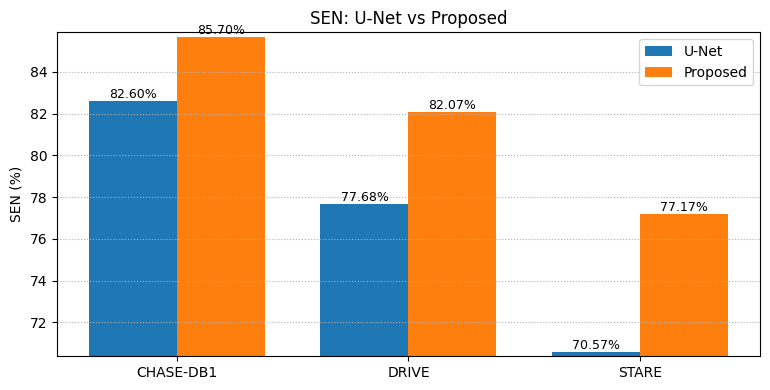

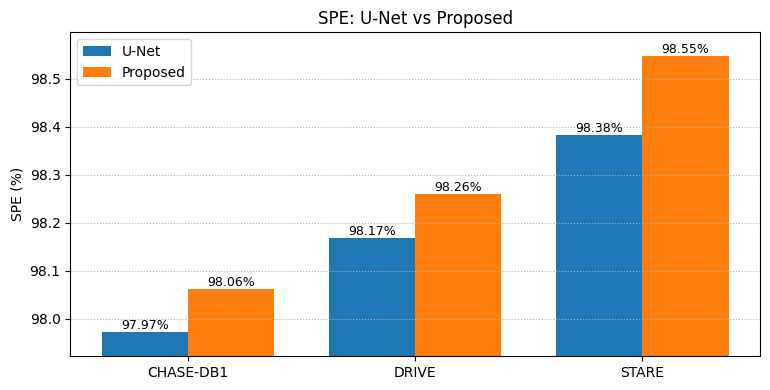

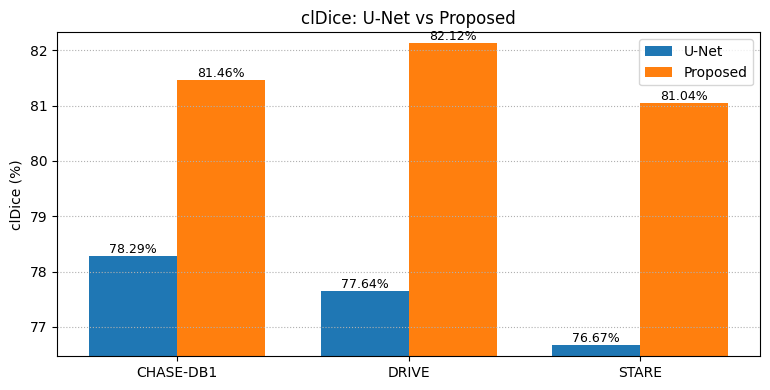

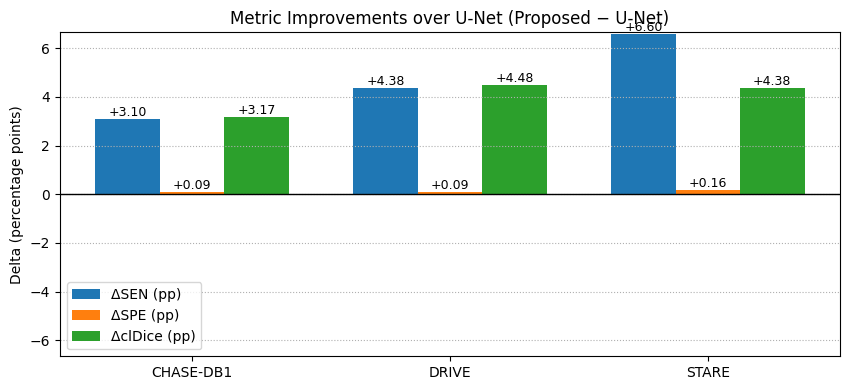

In [ ]:
# ================== Matplotlib charts (percent scale + zoomed axes) ==================

import numpy as np
import matplotlib.pyplot as plt

# Per-metric formatting + padding (in percentage points)
_METRIC_FMT = {
    "SEN":    dict(decimals=2, pad_pp=0.20),   # e.g., 82.03% ±0.20 pp
    "SPE":    dict(decimals=2, pad_pp=0.05),   # tiny diffs; tighter padding
    "clDice": dict(decimals=2, pad_pp=0.20),
}

def _pp(val):  # percentage points
    return 100.0 * float(val)

def plot_grouped_metric(df, metric_name):
    cfg = _METRIC_FMT.get(metric_name, dict(decimals=2, pad_pp=0.2))
    dec = cfg["decimals"]
    pad = cfg["pad_pp"]  # absolute padding in percentage points

    ds = sorted(df['Dataset'].unique())
    x = np.arange(len(ds))
    width = 0.38

    vals_unet = [df[(df.Dataset==d)&(df.Model=="U-Net")][metric_name].values[0] for d in ds]
    vals_prop = [df[(df.Dataset==d)&(df.Model=="Proposed")][metric_name].values[0] for d in ds]

    # Convert to percentage points
    u_pp = np.array([_pp(v) for v in vals_unet])
    p_pp = np.array([_pp(v) for v in vals_prop])

    vmin = min(u_pp.min(), p_pp.min())
    vmax = max(u_pp.max(), p_pp.max())
    ymin = max(0.0, vmin - pad)
    ymax = min(100.0, vmax + pad)

    plt.figure(figsize=(7.8, 4.0))
    b1 = plt.bar(x - width/2, u_pp, width, label='U-Net')
    b2 = plt.bar(x + width/2, p_pp, width, label='Proposed')

    # Annotations
    for b in list(b1) + list(b2):
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h,
                 f"{h:.{dec}f}%", ha='center', va='bottom', fontsize=9)

    plt.xticks(x, ds)
    plt.ylabel(f"{metric_name} (%)")
    plt.title(f"{metric_name}: U-Net vs Proposed")
    plt.ylim(ymin, ymax)
    plt.grid(True, axis='y', linestyle=':', linewidth=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_deltas(df_delta):
    # convert deltas to percentage points and auto-zoom around 0
    ds = sorted(df_delta['Dataset'].unique())
    x = np.arange(len(ds))
    width = 0.25

    dSEN_pp = np.array([_pp(df_delta[df_delta.Dataset==d]['dSEN'].values[0])    for d in ds])
    dSPE_pp = np.array([_pp(df_delta[df_delta.Dataset==d]['dSPE'].values[0])    for d in ds])
    dcl_pp  = np.array([_pp(df_delta[df_delta.Dataset==d]['dclDice'].values[0]) for d in ds])

    all_pp = np.concatenate([dSEN_pp, dSPE_pp, dcl_pp])
    max_abs = float(np.abs(all_pp).max()) if all_pp.size else 0.0
    pad = 0.05  # pp
    ylim = max(0.25, max_abs + pad)  # keep some minimum scale

    plt.figure(figsize=(8.6, 4.0))
    plt.bar(x - width, dSEN_pp, width, label='ΔSEN (pp)')
    plt.bar(x,          dSPE_pp, width, label='ΔSPE (pp)')
    plt.bar(x + width,  dcl_pp,  width, label='ΔclDice (pp)')

    # Annotate bars
    def _annot(bx, vals):
        for xi, v in zip(bx, vals):
            plt.text(xi, v, f"{v:+.2f}", ha='center', va='bottom' if v>=0 else 'top', fontsize=9)

    _annot(x - width, dSEN_pp)
    _annot(x,         dSPE_pp)
    _annot(x + width, dcl_pp)

    plt.xticks(x, ds)
    plt.axhline(0, color='k', linewidth=1)
    plt.ylabel('Delta (percentage points)')
    plt.title('Metric Improvements over U-Net (Proposed − U-Net)')
    plt.ylim(-ylim, ylim)
    plt.grid(True, axis='y', linestyle=':', linewidth=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- call exactly as before ----
for metric in ["SEN", "SPE", "clDice"]:
    plot_grouped_metric(df, metric)
plot_deltas(df_delta)


In [ ]:
# === Cell 1: helpers (build right model per dataset + robust ckpt load + viz) ===
import torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------
# 0) Peek #out channels from a checkpoint
# ---------------------------
def peek_out_channels(ckpt_path: str | Path, default=1):
    p = Path(ckpt_path)
    if not p.is_absolute():
        p = (Path.cwd() / p).resolve()
    if not p.exists():
        print(f"[peek_out_channels] WARNING: ckpt not found: {p} → using default={default}")
        return default
    try:
        sd = torch.load(p, map_location="cpu")
    except Exception as e:
        print(f"[peek_out_channels] WARNING: could not load {p}: {e} → using default={default}")
        return default

    # Try common final layer names
    for k in ["final.weight", "out.weight", "classifier.weight", "seg_head.weight"]:
        if k in sd and sd[k].ndim == 4:  # [C_out, C_in, 1, 1] (usually)
            return int(sd[k].shape[0])
    # Fallback: look for any conv weight that has kernel 1x1 and small C_out
    for k, v in sd.items():
        if isinstance(v, torch.Tensor) and v.ndim == 4 and v.shape[-2:] == (1, 1):
            c_out = int(v.shape[0])
            if c_out in (1, 2):
                return c_out

    print(f"[peek_out_channels] Could not infer from {p} → using default={default}")
    return default

# ---------------------------
# 1) Dataset→Proposed-model hyperparams
#    EDIT these to match how you trained each checkpoint.
# ---------------------------
PROPOSED_CFG = {
    "DRIVE":     dict(enh_channels=64, iters=6, threshold_mode="scaled_vat", half_life=2.0, reduce_to=64, base_kwargs={"cbam_reduction": 16}),
    "CHASE-DB1": dict(enh_channels=64, iters=6, threshold_mode="scaled_vat", half_life=2.0, reduce_to=64, base_kwargs={"cbam_reduction": 16}),
    "STARE":     dict(enh_channels=64, iters=6, threshold_mode="scaled_vat", half_life=2.0, reduce_to=64, base_kwargs={"cbam_reduction": 16}),
}

# ---------------------------
# 2) Model builders (now ckpt-aware for UNet)
# ---------------------------
def _make_unet(in_ch=1, out_ch=2):
    from src.models.orig_unet import UNet
    # be flexible with various UNet ctor signatures you used across runs
    for ctor in [
        lambda: UNet(in_channels=in_ch, out_ch=out_ch),
        lambda: UNet(in_channels=in_ch, out_channels=out_ch),
        lambda: UNet(in_ch=in_ch, out_ch=out_ch),
        lambda: UNet(in_ch, out_ch),
        lambda: UNet(in_channels=in_ch),  # fallback (will mismatch if out_ch!=1)
    ]:
        try:
            m = ctor()
            return m
        except TypeError:
            continue
    # Last resort
    return UNet(in_channels=in_ch)

def build_model(kind: str, dataset_name: str, ckpt_path: str | Path | None = None):
    """
    kind ∈ {"unet","proposed"}; dataset_name ∈ {"DRIVE","CHASE-DB1","STARE"}.
    If ckpt_path is provided for UNet, we infer out_channels from the checkpoint.
    """
    kind = kind.lower()
    dn   = dataset_name

    if kind == "unet":
        out_ch = 2 #peek_out_channels(ckpt_path, default=1) if ckpt_path is not None else 1
        model = _make_unet(in_ch=1, out_ch=out_ch)
        print(f"[build_model] {dn} → U-Net(in=1, out={out_ch})")
        return model

    if kind == "proposed":
        from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
        if dn not in PROPOSED_CFG:
            raise KeyError(f"No proposed-config registered for dataset '{dn}'. Add it to PROPOSED_CFG.")
        cfg = PROPOSED_CFG[dn].copy()
        model = DPCNConcatUNet(
            in_ch=1,
            enh_channels=cfg.pop("enh_channels"),
            iters=cfg.pop("iters"),
            threshold_mode=cfg.pop("threshold_mode", "scaled_vat"),
            half_life=cfg.pop("half_life", 2.0),
            reduce_to=cfg.pop("reduce_to", None),
            base_kwargs=cfg.pop("base_kwargs", None),
            **cfg
        )
        tc = model.iters * model.enh_channels
        stem = "Identity" if isinstance(model.stem, torch.nn.Identity) else "1x1 Conv"
        print(f"[build_model] {dn} → DPCNConcatUNet(T={model.iters}, C={model.enh_channels}, T*C={tc}, stem={stem})")
        return model

    raise ValueError(f"Unknown kind='{kind}'")

# ---------------------------
# 3) Robust checkpoint loader
# ---------------------------
def load_weights(model: torch.nn.Module, ckpt_path: str | Path, map_location=None):
    p = Path(ckpt_path)
    if not p.is_absolute():
        p = (Path.cwd() / p).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Checkpoint not found: {p}")

    sd = torch.load(p, map_location=map_location or "cpu")
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing or unexpected:
        print("[load_weights] Warning: state_dict mismatch:")
        if missing:
            print("  missing:", missing[:10], ("..." if len(missing) > 10 else ""))
        if unexpected:
            print("  unexpected:", unexpected[:10], ("..." if len(unexpected) > 10 else ""))
    print(f"[load_weights] Loaded from: {p}")
    return model

# ---------------------------
# 4) Sliding-window inference (returns single FG logit [1,1,H,W])
# ---------------------------
@torch.no_grad()
def sliding_window_forward_logits(model, img_1chw, window=512, overlap=0.25, device="cuda"):
    """
    Returns a single-channel foreground *logit* map [1,1,H,W],
    regardless of whether the model outputs [B,1,H,W] or [B,2,H,W], logits or probs.
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    acc = None
    norm = None

    def _to_binary_logit(out):  # out: [1,C,h,w]
        if out.shape[1] == 1:
            return out  # treat as logit
        elif out.shape[1] == 2:
            is_prob = (out.min() >= 0.0) and (out.max() <= 1.0)
            if is_prob:
                s = out.sum(dim=1, keepdim=True)
                if torch.allclose(s, torch.ones_like(s), atol=1e-3):
                    p_fg = out[:, 1:2]
                    return torch.logit(p_fg.clamp(1e-6, 1-1e-6))  # prob -> logit
            # raw logits: l_fg - l_bg
            return out[:, 1:2] - out[:, 0:1]
        else:
            raise RuntimeError(f"Expected 1 or 2 output channels, got {out.shape[1]}")

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]                     # [1,1,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                out = model(tile)                               # [1,C,win,win]
            logit = _to_binary_logit(out)                       # [1,1,win,win]
            if acc is None:
                acc  = torch.zeros_like(img[:, :1], device=device)  # [1,1,H,W]
                norm = torch.zeros_like(img[:, :1], device=device)
            acc[:, :, y0:y1, x0:x1]  += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    return acc / torch.clamp_min(norm, 1.0)  # [1,1,H,W]

# ---------------------------
# 5) Utilities for binarization & error maps
# ---------------------------
def _to_binary_pred(out_1BCHW, tau=0.5):
    """
    Accepts model output with C in {1,2}, logits or probs.
    Returns binary mask [1,1,H,W] on CPU (float {0,1}).
    """
    out = out_1BCHW
    if out.ndim != 4 or out.size(0) != 1:
        raise ValueError(f"expected [1,C,H,W], got {tuple(out.shape)}")
    C = out.shape[1]
    if C == 1:
        prob = torch.sigmoid(out)
        return (prob >= tau).float().cpu()
    elif C == 2:
        is_prob = (out.min() >= 0) and (out.max() <= 1)
        if is_prob:
            s = out.sum(dim=1, keepdim=True)
            if torch.allclose(s, torch.ones_like(s), atol=1e-3):
                prob_fg = out[:, 1:2]
                return (prob_fg >= tau).float().cpu()
        return (out.argmax(dim=1, keepdim=True) == 1).float().cpu()
    else:
        raise ValueError(f"expected 1 or 2 output channels, got {C}")

def _make_error_rgb(pred01_1hw, gt01_1hw, fov01_1hw=None,
                    tp_color=(1,1,1), fp_color=(0,0,1), fn_color=(1,0,0)):
    """
    pred01_1hw, gt01_1hw, fov01_1hw: torch [1,H,W] on CPU, values {0,1}
    Returns RGB float32 array [H,W,3] with TP=white, FP=blue, FN=red, TN/FOV-out=black.
    """
    p = (pred01_1hw.squeeze(0) > 0.5)
    g = (gt01_1hw.squeeze(0)   > 0.5)
    m = (fov01_1hw.squeeze(0) > 0.5) if fov01_1hw is not None else torch.ones_like(g, dtype=torch.bool)

    tp = (p & g & m)
    fp = (p & (~g) & m)
    fn = ((~p) & g & m)

    H, W = g.shape
    rgb = torch.zeros((H, W, 3), dtype=torch.float32)
    if tp.any(): rgb[tp] = torch.tensor(tp_color, dtype=torch.float32)
    if fp.any(): rgb[fp] = torch.tensor(fp_color, dtype=torch.float32)
    if fn.any(): rgb[fn] = torch.tensor(fn_color, dtype=torch.float32)
    rgb[~m] = 0.0
    return rgb.numpy()

def _mask_to_rgb01(mask_1chw, fov_1chw=None):
    """
    mask_1chw: torch [1,1,H,W] with {0,1}
    fov_1chw : optional torch [1,1,H,W] with {0,1}
    Returns RGB float [H,W,3] with white=1 on vessels, black elsewhere (outside FOV black).
    """
    m = (mask_1chw.detach().cpu()[0,0] > 0.5).numpy().astype(np.float32)  # [H,W]
    rgb = np.repeat(m[..., None], 3, axis=2)
    if fov_1chw is not None:
        f = (fov_1chw.detach().cpu()[0,0] > 0.5).numpy().astype(bool)
        rgb[~f] = 0.0
    return rgb

def show_two_rows_inline(
    dname, img_stem,
    gt01_1chw,                   # [1,1,H,W] binary GT
    mathfi_out_1BCHW,            # [1,C,H,W] (logits or probs; 1 or 2 channels)
    unet_out_1BCHW,              # [1,C,H,W]
    fov01_1chw=None,             # optional [1,1,H,W]
    tau=0.5
):
    # Ensure CPU tensors
    gt01  = (gt01_1chw.detach().cpu()  > 0.5).float()
    fov01 = (fov01_1chw.detach().cpu() > 0.5).float() if fov01_1chw is not None else None

    # Binarize preds -> [1,1,H,W]
    mathfi_pred01 = _to_binary_pred(mathfi_out_1BCHW.detach().cpu(), tau=tau)
    unet_pred01   = _to_binary_pred(unet_out_1BCHW.detach().cpu(),   tau=tau)

    # Build GT RGB once (white vessels)
    gt_rgb = _mask_to_rgb01(gt01, fov01)

    # Predicted RGB (white vessels)
    mathfi_pred_rgb = _mask_to_rgb01(mathfi_pred01, fov01)
    unet_pred_rgb   = _mask_to_rgb01(unet_pred01,   fov01)

    # Error maps (TP=white, FP=blue, FN=red)
    mathfi_err_rgb = _make_error_rgb(mathfi_pred01[0], gt01[0], fov01[0] if fov01 is not None else None)
    unet_err_rgb   = _make_error_rgb(unet_pred01[0],   gt01[0], fov01[0]  if fov01 is not None else None)

    # Plot 2x3
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"{dname} [{img_stem}]", fontsize=12)

    # Row 1 — MATHFI
    axs[0,0].imshow(gt_rgb);           axs[0,0].set_title("GT");               axs[0,0].axis('off')
    axs[0,1].imshow(mathfi_pred_rgb);  axs[0,1].set_title("MATHFI Predicted"); axs[0,1].axis('off')
    axs[0,2].imshow(mathfi_err_rgb);   axs[0,2].set_title("MATHFI TP/FP/FN");  axs[0,2].axis('off')

    # Row 2 — U-Net
    axs[1,0].imshow(gt_rgb);           axs[1,0].set_title("GT");               axs[1,0].axis('off')
    axs[1,1].imshow(unet_pred_rgb);    axs[1,1].set_title("U-Net Predicted");  axs[1,1].axis('off')
    axs[1,2].imshow(unet_err_rgb);     axs[1,2].set_title("U-Net TP/FP/FN");   axs[1,2].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [102]:
# ---- FN heatmaps (one figure, two rows: MATHFI and U-Net) -------------------
import numpy as np
import matplotlib.pyplot as plt

def show_fn_heatmap_rows(
    gt01_1chw,
    prob_mathfi_1chw,
    prob_unet_1chw,
    *,
    dname=None,
    img_stem=None,
    tau=0.5,
    cmap_prob="turbo",     # striking for probability
    cmap_fn="inferno"      # high-contrast for FN severity
):
    """
    One figure:
      Row 1 (MATHFI):   GT | Probability | FN severity (+ colorbars on the right of Prob/FN)
      Row 2 (U-Net):    GT | Probability | FN severity (+ colorbars on the right of Prob/FN)

    FN severity = distance_to_GT_boundary × (1 − probability)
    Brighter = deeper miss with lower confidence (worse for sensitivity).
    """
    # lazy import EDT; auto-install if missing (notebook-friendly)
    try:
        from scipy.ndimage import distance_transform_edt as EDT
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
        from scipy.ndimage import distance_transform_edt as EDT

    # tensors -> numpy
    gt  = (gt01_1chw[0,0].detach().cpu().numpy() > 0.5).astype(np.uint8)
    pA  =  prob_mathfi_1chw[0,0].detach().cpu().numpy().astype(np.float32)
    pB  =  prob_unet_1chw[0,0].detach().cpu().numpy().astype(np.float32)

    # FN masks @ tau
    fnA = (gt == 1) & (pA < tau)
    fnB = (gt == 1) & (pB < tau)

    # distance inside GT to boundary
    dist_in = EDT(gt.astype(bool)).astype(np.float32)

    # FN severity = depth × (1 − prob)
    scoreA = np.zeros_like(pA, dtype=np.float32); scoreA[fnA] = dist_in[fnA] * (1.0 - pA[fnA])
    scoreB = np.zeros_like(pB, dtype=np.float32); scoreB[fnB] = dist_in[fnB] * (1.0 - pB[fnB])

    # shared FN color scale across both rows
    pos_vals = np.concatenate([scoreA[scoreA > 0], scoreB[scoreB > 0]])
    vmax_fn = float(np.percentile(pos_vals, 95)) if pos_vals.size else 1.0

    # figure
    title_prefix = f"{dname} [{img_stem}]" if (dname or img_stem) else ""
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"{title_prefix} — False-Negative Analysis (brighter = worse miss)", fontsize=13, weight="bold")

    # --- Row 1: MATHFI ---
    axs[0,0].imshow(gt, cmap="gray");                    axs[0,0].set_title("MATHFI — Ground Truth");        axs[0,0].axis("off")
    im_pA = axs[0,1].imshow(pA, vmin=0, vmax=1, cmap=cmap_prob)
    axs[0,1].set_title("MATHFI — Probability");          axs[0,1].axis("off")
    im_fA = axs[0,2].imshow(scoreA, vmin=0, vmax=vmax_fn, cmap=cmap_fn)
    axs[0,2].set_title("MATHFI — FN Severity (depth × (1−p))"); axs[0,2].axis("off")
    fig.colorbar(im_pA, ax=axs[0,1], fraction=0.046, pad=0.04, label="Probability")
    fig.colorbar(im_fA, ax=axs[0,2], fraction=0.046, pad=0.04, label="FN severity")

    if not np.any(fnA):
        axs[0,2].text(0.5, 0.5, "No FNs", color="w", ha="center", va="center", transform=axs[0,2].transAxes)

    # --- Row 2: U-Net ---
    axs[1,0].imshow(gt, cmap="gray");                    axs[1,0].set_title("U-Net — Ground Truth");          axs[1,0].axis("off")
    im_pB = axs[1,1].imshow(pB, vmin=0, vmax=1, cmap=cmap_prob)
    axs[1,1].set_title("U-Net — Probability");           axs[1,1].axis("off")
    im_fB = axs[1,2].imshow(scoreB, vmin=0, vmax=vmax_fn, cmap=cmap_fn)
    axs[1,2].set_title("U-Net — FN Severity (depth × (1−p))");   axs[1,2].axis("off")
    fig.colorbar(im_pB, ax=axs[1,1], fraction=0.046, pad=0.04, label="Probability")
    fig.colorbar(im_fB, ax=axs[1,2], fraction=0.046, pad=0.04, label="FN severity")

    if not np.any(fnB):
        axs[1,2].text(0.5, 0.5, "No FNs", color="w", ha="center", va="center", transform=axs[1,2].transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()



=== DRIVE ===


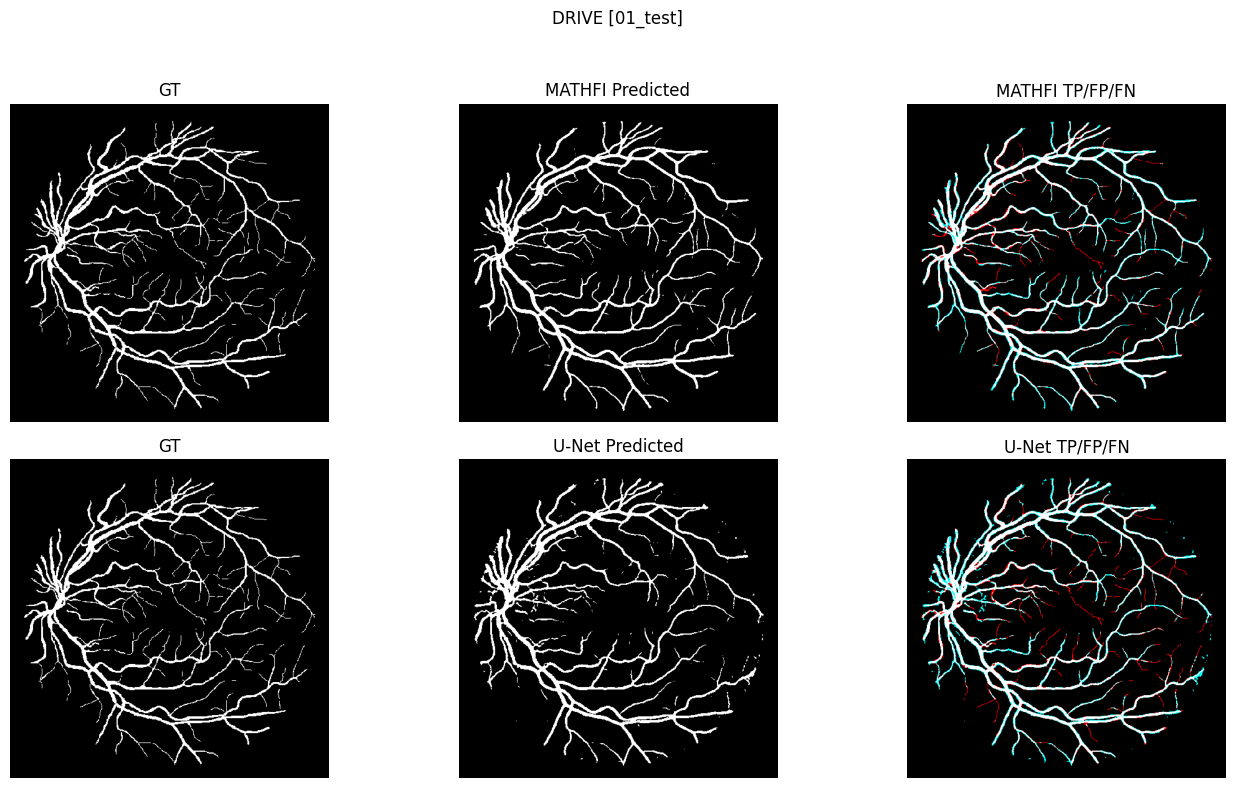

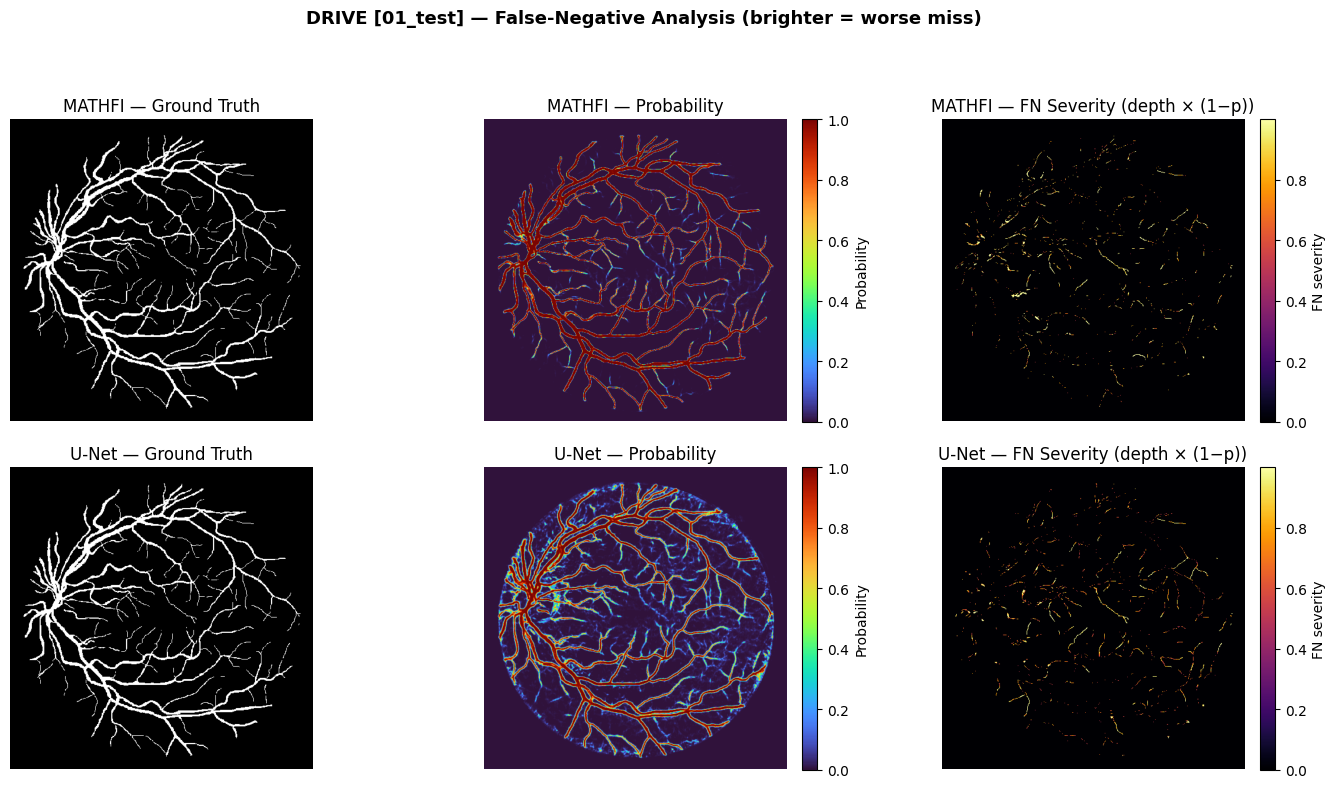

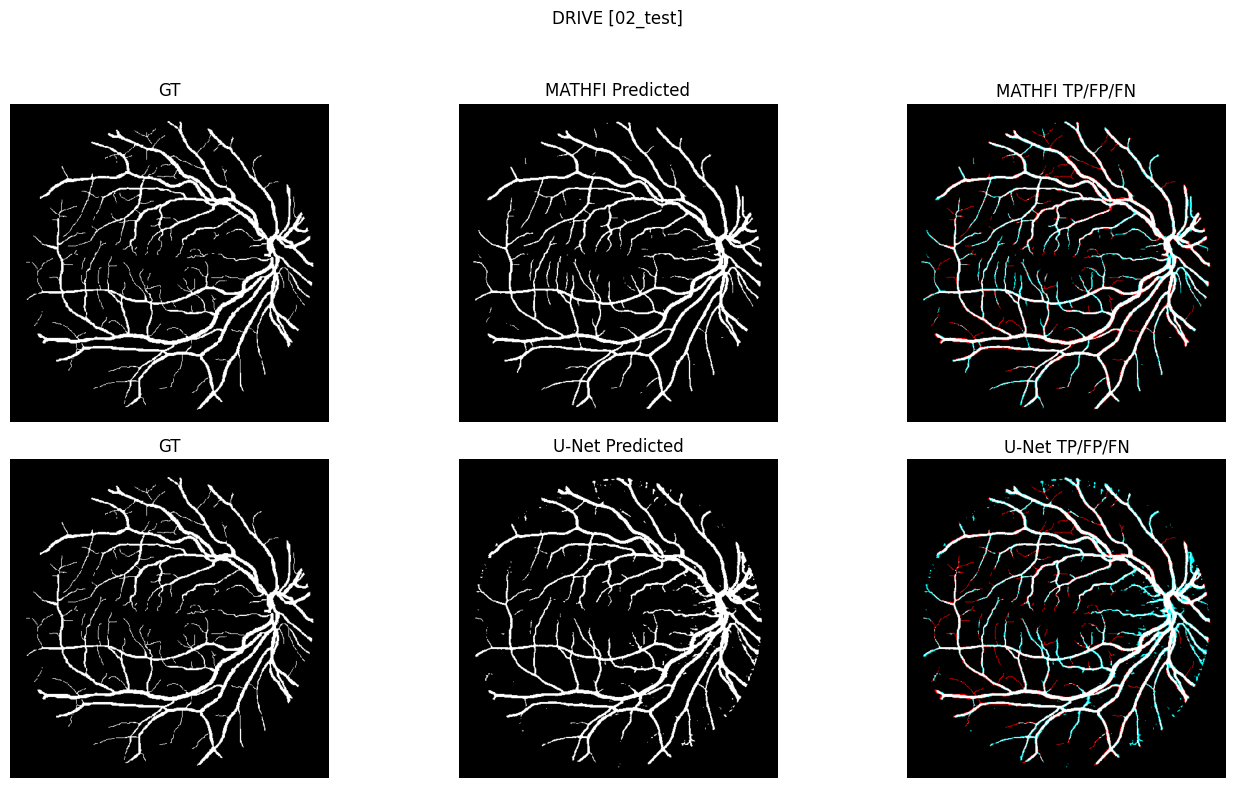

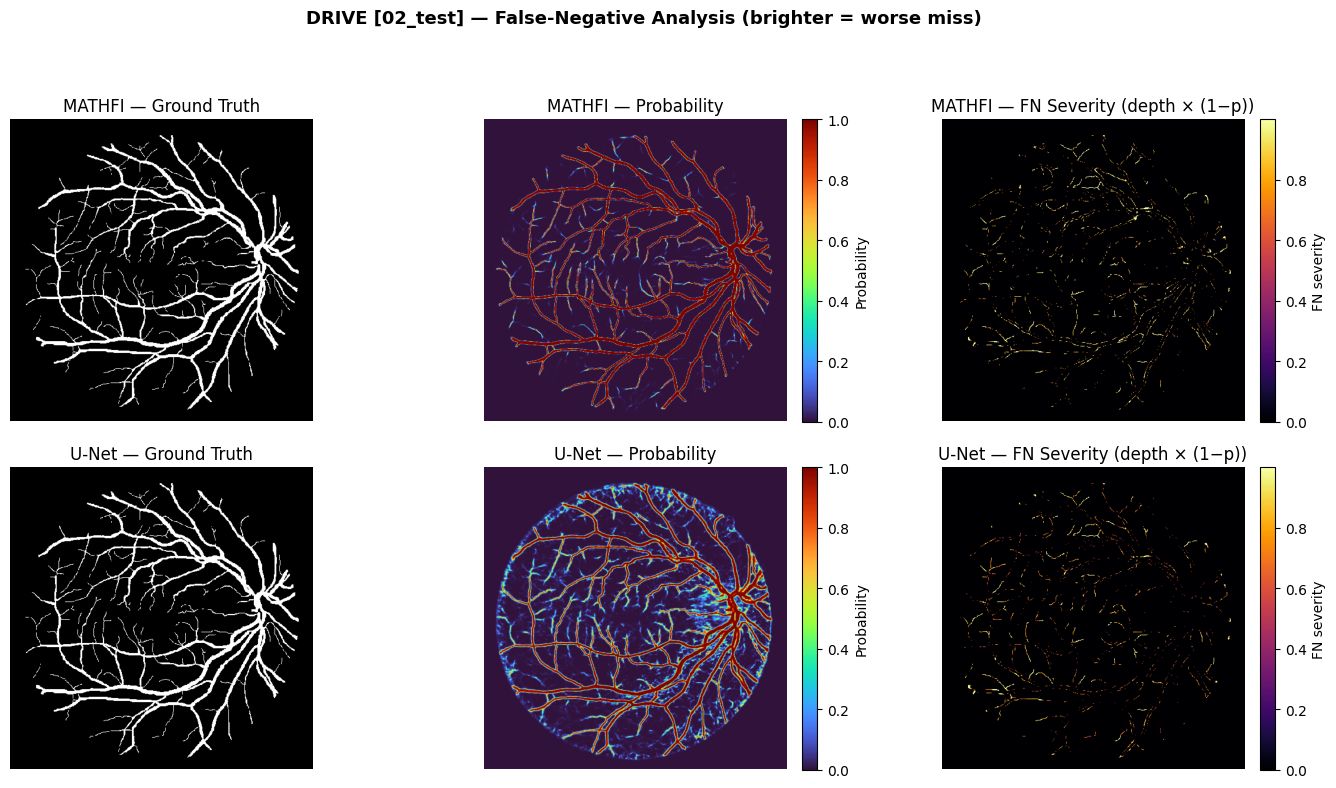

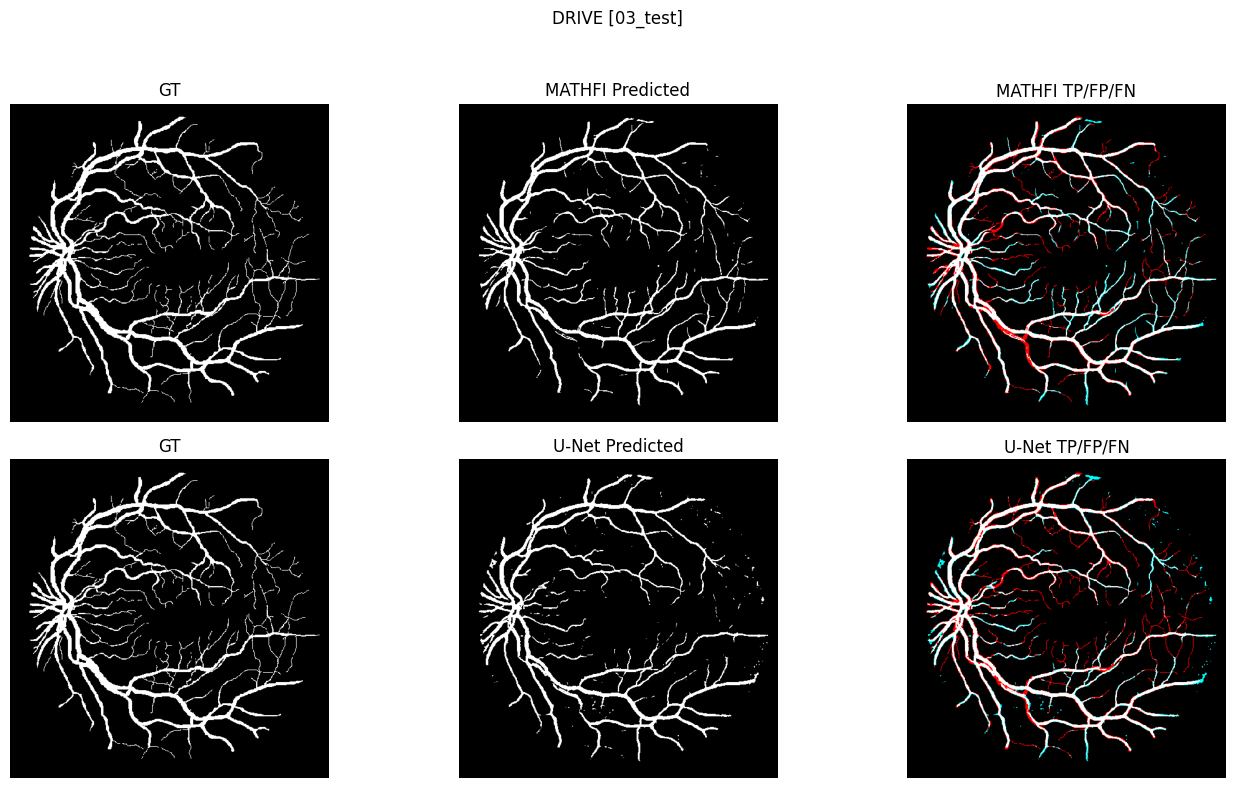

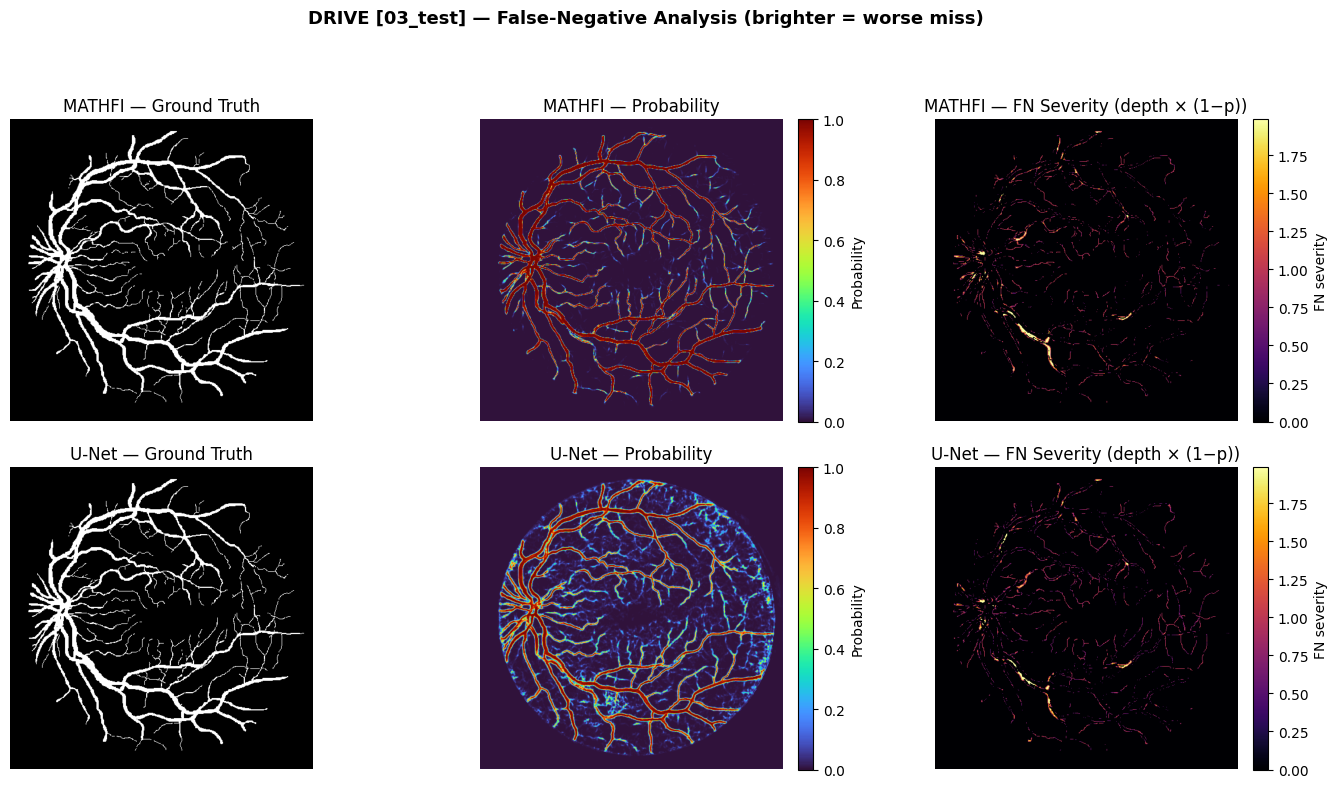

KeyboardInterrupt: 

In [103]:
# Cell: 2-row panel per image — (GT, Pred, TP/FP/FN) for MATHFI and U-Net
import torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

def _mask_to_rgb01(mask_1chw, fov_1chw=None):
    """
    mask_1chw: torch [1,1,H,W] with {0,1}
    fov_1chw : optional torch [1,1,H,W] with {0,1}
    Returns RGB float [H,W,3] with white=1 on vessels, black elsewhere (outside FOV black).
    """
    m = (mask_1chw.detach().cpu()[0,0] > 0.5).numpy().astype(np.float32)  # [H,W]
    rgb = np.repeat(m[..., None], 3, axis=2)
    if fov_1chw is not None:
        f = (fov_1chw.detach().cpu()[0,0] > 0.5).numpy().astype(bool)
        rgb[~f] = 0.0
    return rgb

def show_two_rows_inline(
    dname, img_stem,
    gt01_1chw,                   # [1,1,H,W] binary GT
    mathfi_out_1BCHW,            # [1,C,H,W] (logits or probs; 1 or 2 channels)
    unet_out_1BCHW,              # [1,C,H,W]
    fov01_1chw=None,             # optional [1,1,H,W]
    tau=0.5
):
    # Ensure CPU tensors
    gt01  = (gt01_1chw.detach().cpu()  > 0.5).float()
    fov01 = (fov01_1chw.detach().cpu() > 0.5).float() if fov01_1chw is not None else None

    # Binarize preds -> [1,1,H,W]
    mathfi_pred01 = _to_binary_pred(mathfi_out_1BCHW.detach().cpu(), tau=tau)
    unet_pred01   = _to_binary_pred(unet_out_1BCHW.detach().cpu(),   tau=tau)

    # Build GT RGB once (white vessels)
    gt_rgb = _mask_to_rgb01(gt01, fov01)

    # Predicted RGB (white vessels)
    mathfi_pred_rgb = _mask_to_rgb01(mathfi_pred01, fov01)
    unet_pred_rgb   = _mask_to_rgb01(unet_pred01,   fov01)

    # Error maps (TP=white, FP=blue, FN=red)
    mathfi_err_rgb = _make_error_rgb(mathfi_pred01[0], gt01[0], fov01[0] if fov01 is not None else None)
    unet_err_rgb   = _make_error_rgb(unet_pred01[0],   gt01[0], fov01[0]  if fov01 is not None else None)

    # Plot 2x3
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"{dname} [{img_stem}]", fontsize=12)

    # Row 1 — MATHFI
    axs[0,0].imshow(gt_rgb);           axs[0,0].set_title("GT");                         axs[0,0].axis('off')
    axs[0,1].imshow(mathfi_pred_rgb);  axs[0,1].set_title("MATHFI Predicted");           axs[0,1].axis('off')
    axs[0,2].imshow(mathfi_err_rgb);   axs[0,2].set_title("MATHFI TP/FP/FN");            axs[0,2].axis('off')

    # Row 2 — U-Net
    axs[1,0].imshow(gt_rgb);           axs[1,0].set_title("GT");                         axs[1,0].axis('off')
    axs[1,1].imshow(unet_pred_rgb);    axs[1,1].set_title("U-Net Predicted");            axs[1,1].axis('off')
    axs[1,2].imshow(unet_err_rgb);     axs[1,2].set_title("U-Net TP/FP/FN");             axs[1,2].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def visualize_all_two_rows_inline(
    DATASETS, CKPTS,
    tau=0.5,
    image_size=512,
    window=None,
    overlap=0.25,
    device=None,
    num_workers=0,
    seed=1337,
    max_samples=None
):
    """
    For each dataset: iterate test set, run MATHFI & U-Net (sliding window),
    show per-image 2x3 panels (GT|Pred|TP/FP/FN) and FN heatmaps for both models.
    """
    # Resolve defaults so you don't need globals
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    window = window or image_size

    # Choose the logits tiler (your code may define either name)
    logits_fn = (
        sliding_window_forward_logits_1chw
        if 'sliding_window_forward_logits_1chw' in globals()
        else sliding_window_forward_logits
    )

    for dname, cfg in DATASETS.items():
        print(f"\n=== {dname} ===")
        # -- build loader
        test_loader = make_test_loader_for_dataset(
            root=cfg["root"], label_folder=cfg["label_folder"],
            image_size=image_size, batch_size=1, num_workers=num_workers, seed=seed
        )

        # -- build & load models *for this dataset*
        m_mathfi = load_weights(build_model("proposed", dname), CKPTS[dname]["proposed"]).to(device).eval()
        m_unet   = load_weights(build_model("unet",     dname), CKPTS[dname]["unet"]).to(device).eval()

        shown = 0
        for bidx, batch in enumerate(test_loader):
            x   = batch["image"].to(device)  # [B,1,H,W]
            y   = batch["mask"].to(device)   # [B,1,H,W]
            fov = batch.get("fov", torch.ones_like(y)).to(device)

            # filename for title
            if "image_path" in batch and isinstance(batch["image_path"], list) and len(batch["image_path"]) > 0:
                img_stem = Path(batch["image_path"][0]).stem
            elif "image_path" in batch and isinstance(batch["image_path"], str):
                img_stem = Path(batch["image_path"]).stem
            else:
                img_stem = f"sample_{bidx:03d}"

            # If batch size ever >1, loop per item
            for i in range(x.size(0)):
                xi   = x[i:i+1]     # [1,1,H,W]
                yi   = y[i:i+1]     # [1,1,H,W]
                fovi = fov[i:i+1]   # [1,1,H,W]

                # --- tiled logits (single-channel) ---
                logit_mathfi = logits_fn(m_mathfi, xi, window=window, overlap=overlap, device=device)
                logit_unet   = logits_fn(m_unet,   xi, window=window, overlap=overlap, device=device)

                # --- your existing 2×3 panel ---
                show_two_rows_inline(
                    dname=dname, img_stem=img_stem,
                    gt01_1chw=yi.detach().cpu(),
                    mathfi_out_1BCHW=logit_mathfi.detach().cpu(),
                    unet_out_1BCHW=logit_unet.detach().cpu(),
                    fov01_1chw=fovi.detach().cpu(),
                    tau=tau
                )

                
                # --- HEATMAPS: one figure with both models ---
                try:
                    prob_mathfi = torch.sigmoid(logit_mathfi).cpu()
                    prob_unet   = torch.sigmoid(logit_unet).cpu()

                    show_fn_heatmap_rows(
                        gt01_1chw=yi.cpu(),
                        prob_mathfi_1chw=prob_mathfi,
                        prob_unet_1chw=prob_unet,
                        dname=dname,
                        img_stem=img_stem,
                        tau=tau,                # or TAU
                        cmap_prob="turbo",      # striking
                        cmap_fn="inferno"       # high-contrast for FN severity
                    )
                except NameError:
                    pass



                shown += 1
                if max_samples is not None and shown >= max_samples:
                    return  # stop early

# Example run (inline only, no saving)
visualize_all_two_rows_inline(
    DATASETS=DATASETS,
    CKPTS=CKPTS,
    tau=TAU,                # e.g., 0.5
    window=WINDOW,          # e.g., 256 or 512
    overlap=OVERLAP,        # e.g., 0.25
    device=DEVICE,
    max_samples=None        # or an int to preview
)